<a href="https://colab.research.google.com/github/yonaanda/Analisis-Visualisasi-Data/blob/main/UTS/UTS_AVD_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Analisis Fitur


Fitur dibagi menjadi dua kelompok berdasarkan nilai median:
   high: nilai fitur >= median
   low: nilai fitur < media


In [ ]:
import pandas as pd

df = pd.read_csv('winequality-red.csv')

# Fitur-fitur yang akan digunakan
features = ['alcohol', 'pH', 'residual sugar', 'citric acid']

# Melakukan loop untuk analisis fitur
for x in features:
    nilai_median = df[x].median()

    # Mengelompokan group high dan low
    high_group = df[df[x] >= nilai_median]
    low_group = df[df[x] < nilai_median]

    # Menghitung rata-rata dari kolom quality
    high_mean = high_group['quality'].mean()
    low_mean = low_group['quality'].mean()

    print(x)
    print(f"high    {high_mean:.6f}")
    print(f"low     {low_mean:.6f}")
    print("Name: quality, dtype: float64\n")

alcohol
high    5.958904
low     5.310302
Name: quality, dtype: float64

pH
high    5.598039
low     5.675607
Name: quality, dtype: float64

residual sugar
high    5.665880
low     5.602394
Name: quality, dtype: float64

citric acid
high    5.822360
low     5.447103
Name: quality, dtype: float64



Penjelasan:
1. Alcohol: Anggur dengan kadar alkohol tinggi memiliki rata-rata kualitas yang jauh lebih tinggi (5.96) dibandingkan kadar alkohol rendah (5.31)
2. pH: Anggur dengan pH lebih rendah memiliki kualitas rata-rata sedikit lebih baik (5.68) daripada yang ber-pH tinggi (5.60)
3. Residual Sugar: Perbedaan kadar gula sisa antara tinggi dan rendah tidak memberikan perbedaan kualitas yang signifikan (5.67) dan (5.60).
4. Citric Acid: Anggur dengan kandungan asam sitrat tinggi memiliki rata-rata kualitas lebih baik (5.82) dibandingkan yang rendah (5.45).

# B. Explatory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Melihat 5 baris pertama dari dataset sekaligus mengecek dataset berhasil dibaca
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Mengetahui deskripsi nilai statistika dari masing masing kolom
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


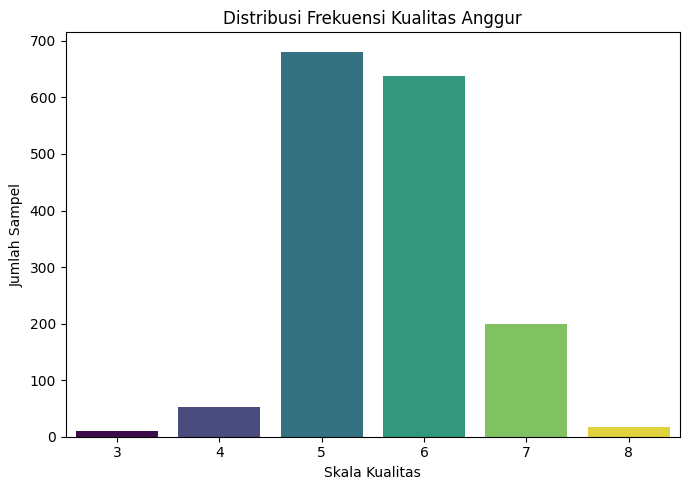

In [ ]:
# Bar Plot untuk Variabel Target (Quality)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='quality', palette='viridis', hue='quality', legend=False)
plt.title('Distribusi Frekuensi Kualitas Anggur')
plt.xlabel('Skala Kualitas')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()


Mayoritas anggur berada pada kualitas menengah, yaitu skor 5 dan 6. Sangat sedikit anggur yang memiliki kualitas sangat buruk (skor 3 atau 4) ataupun kualitas sangat baik (skor 7 atau 8). Ini menunjukkan adanya ketimpangan kelas pada data target.

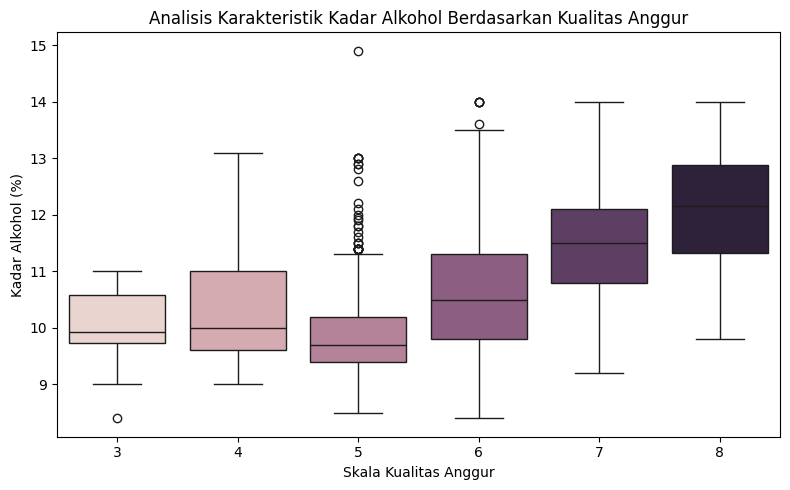

In [ ]:
# Box Plot Hubungan antara Fitur Alkohol dengan Skala Kualitas Target
plt.figure(figsize=(8, 5))
sns.boxplot(x='quality', y='alcohol', data=df, hue='quality', legend=False)
plt.title('Analisis Karakteristik Kadar Alkohol Berdasarkan Kualitas Anggur')
plt.xlabel('Skala Kualitas Anggur')
plt.ylabel('Kadar Alkohol (%)')
plt.tight_layout()
plt.show()

Berdasarkan grafik Box Plot yang dihasilkan, kita dapat menarik beberapa kesimpulan penting:

1. Letak kotak dan garis median semakin bergeser ke atas seiring meningkatnya skala kualitas terutama dari rating 5 hingga 8. Hal ini membuktikan bahwa semakin tinggi kadar alkohol pada anggur, cenderung semakin tinggi pula rating kualitas yang diberikan oleh para ahli.
2. Kelompok anggur kualitas rendah (skor 3 dan 4) memiliki kotak distribusi yang berada di area bawah, mengindikasikan bahwa anggur dengan kadar alkohol rendah lebih rentan mendapatkan penilaian kualitas yang buruk.
3. Pada kualitas rating 5 dan 6, terlihat beberapa outlier yang menandakan beberapa sampel anggur berkadar alkohol tinggi (12% - 15%) namun tetap mendapatkan rating kualitas yang sedang/rendah. Artinya, meskipun kadar alkohol berperan besar, terdapat faktor lain yang mempengaruhi penilaian akhir sampel tersebut.

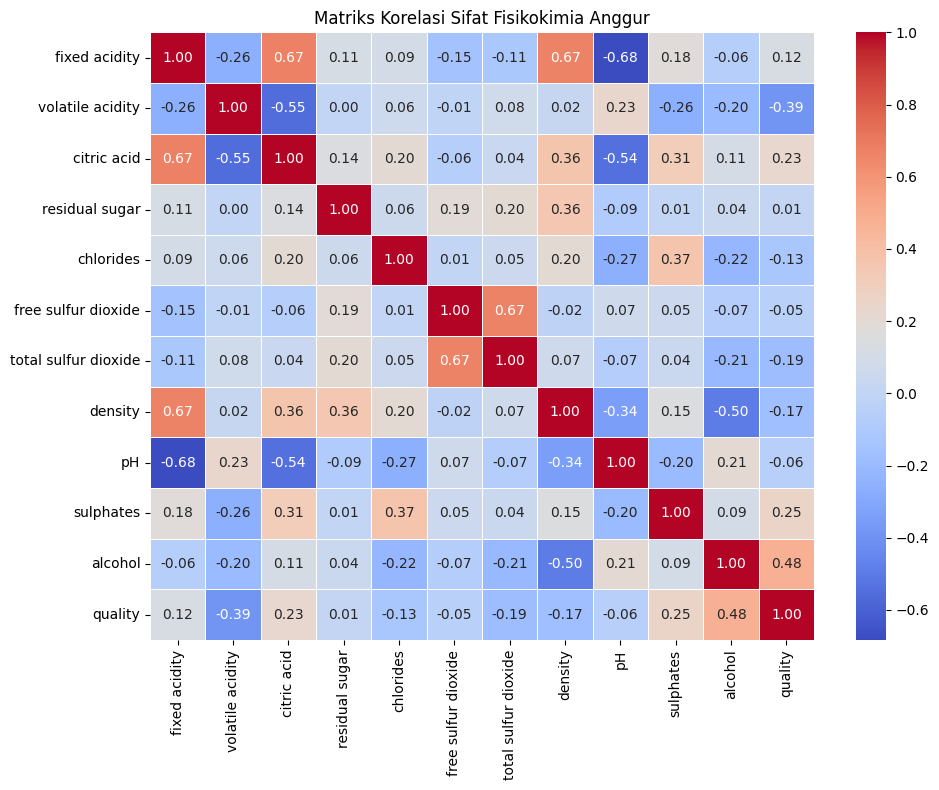

In [ ]:
# Heatmap Matriks Korelasi
plt.figure(figsize=(10, 8))
matriks_korelasi = df.corr()
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Sifat Fisikokimia Anggur')
plt.tight_layout()
plt.show()

 Alkohol adalah pendorong utama tingginya kualitas anggur, hal ini
ditunjukkan dengan nilai korelasi yang paling tinggi (alcohol = +0.48)
 Asam atsiri yang terlalu tinggi menandakan adanya kandungan asam asetat yang berlebih (seperti rasa cuka). Hal ini merusak aroma dan rasa, sehingga berbanding terbalik dengan kualitas anggur, ditandai dengan nilai korelasi negatif terbesar (volatile acidity = -0.39)